# Exploratory Data Analysis: The QUEST Framework in Practice



This notebook demonstrates the QUEST EDA Framework using three real-world messy datasets, each chosen because it exposes different categories of data quality challenges that analysts encounter in practice.

The QUEST framework organizes exploratory data analysis into five interconnected phases:

| Phase | Name | Focus |
|-------|------|-------|
| Q | Question | Define the analytical mission: stakeholder needs, constraints, success criteria, and the questions the analysis must answer |
| U | Understand | Audit the data's structure, types, granularity, provenance, and quality; assess missingness mechanisms and data integrity |
| E | Explore | Profile each variable individually through distributions, summary statistics, and transformations; identify outliers, skewness, and modality |
| S | Study | Examine relationships between variables using bivariate and multivariate methods, including model-based discovery (trees, clustering, PCA) |
| T | Tell | Synthesize findings into a coherent narrative, communicate results to the intended audience, and identify the next iteration of questions |

Three iteration loops keep the process adaptive rather than linear. The Discovery Loop (T to Q) generates new questions from findings. The Modeling Loop (S back to E or S) refines exploration when models reveal unexpected structure. The Quality Loop (any phase back to U) returns to data auditing whenever an anomaly surfaces.

| Dataset | Domain | Key EDA Challenges |
|---------|--------|--------------------|
| Hospital Readmissions | Healthcare | Mixed types, class imbalance, clinical coding inconsistencies, MNAR missingness |
| EPA Air Quality | Environmental | Sensor gaps, temporal drift, seasonal patterns, extreme outliers |
| US Census ACS | Survey/Demographic | Survey weights, high-cardinality categoricals, coded missingness, ordinal variables |

Each dataset is a realistic synthetic version that faithfully reproduces the messiness patterns found in the original public data sources (CMS Hospital Compare, EPA AQS, Census PUMS), ensuring that the pedagogical value of the exercises does not depend on external data access.

## Setup and Imports

In [2]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --------------------- ------------------ 4.5/8.3 MB 29.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 32.0 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ----- ---------------------------------- 5.2/37.3 MB 25.9 MB/s eta 0:00:02
   ---------------- ----------------------- 15.2/37.3 MB 36.3 MB/s eta 0:00:01
   ------------------------- -------------- 23.3/37.3 MB 37.5 MB/s eta 0:00:01
   ---------------------------------- ----- 32.5/37.3 MB 39.7 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 37.6 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- --

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

---

# Dataset 1: Hospital Readmissions

This dataset simulates the CMS Hospital Readmissions Reduction Program data. It contains patient-level records from New York State hospitals with the kinds of messiness that healthcare data routinely exhibits: inconsistent categorical coding, clinically implausible values, class imbalance in the target variable, and missingness that is not random but systematically related to patient acuity.

## Q: Question — Define the Analytical Mission

Hospital readmissions within 30 days of discharge are one of the most scrutinized quality metrics in American healthcare. Under the Hospital Readmissions Reduction Program, the Centers for Medicare and Medicaid Services penalizes hospitals with excess readmission rates by reducing their Medicare reimbursement, creating direct financial consequences that can reach millions of dollars per year for large institutions. Beyond the financial dimension, avoidable readmissions represent a failure of care coordination: patients who return to the hospital within a month often experienced inadequate discharge planning, insufficient follow-up, or complications that could have been anticipated. The analytical challenge is that readmission risk depends on a tangle of clinical severity, social determinants, and health system factors, all of which interact in ways that simple tabulations cannot capture. Our data comes from New York State hospitals and carries the quality issues typical of electronic health records merged across systems with different coding conventions, different EHR vendors, and varying documentation practices.

With that context, we frame four questions that our EDA will address:

1. What patient and hospital characteristics are associated with 30-day readmission?
2. Are there systematic patterns in the data quality that could bias our analysis?
3. Which features show the strongest univariate association with the readmission outcome?
4. Are there interaction effects between patient demographics and clinical variables?

Audience: Clinical analytics team and hospital quality improvement officers.
Constraints: Patient privacy requires aggregated reporting; no individual-level identifiers in outputs.

## U: Understand — Acquire, Inspect, and Audit Data Quality

In [4]:
# Load pre-generated hospital readmissions data
# (see generate_datasets.py for the data generation code)
hospital_df = pd.read_csv('hospital_readmissions.csv', parse_dates=['admit_date'])

print(f'Dataset shape: {hospital_df.shape}')
print(f'Readmission rate: {hospital_df["readmitted_30day"].mean():.1%}')
hospital_df.head(10)

Dataset shape: (5025, 15)
Readmission rate: 18.5%


,patient_id,admit_date,age,gender,race_ethnicity,insurance,primary_diagnosis,charlson_index,prior_admissions_12mo,length_of_stay,hemoglobin,creatinine,discharge_disposition,hospital_id,readmitted_30day
0,1,2024-05-07,75,F,Hispanic,Medicare,NaN,1,0,4,13.9,1.04,Home,39,1
1,2,2024-05-24,65,Male,Declined,NaN,J44.1,5,6,5,10.0,NaN,Expired,39,0
2,3,2024-02-10,77,F,White/Non-Hispanic,Medicare,I50.9,2,2,8,14.2,1.28,Rehab,25,0
3,4,2024-07-25,90,M,White,Medicaid,I50.9,0,0,1,13.6,1.04,Home,16,0
4,5,2024-04-30,64,M,NaN,NaN,E11.9,1,1,2,15.4,0.61,Expired,6,0
5,6,2024-08-06,64,F,Declined,Medicaid,K92.0,4,3,5,13.7,1.86,Rehab,7,1
6,7,2024-12-17,91,Female,White/Non-Hispanic,Medicare,CHF,3,4,3,13.1,0.87,Home,21,0
7,8,2024-02-11,79,Female,Unknown,Medicare,j18.9,2,3,6,12.4,1.17,Home,49,0
8,9,2024-07-02,60,Male,NaN,Medicare,J18.9,0,1,1,15.6,0.89,Rehab,32,0
9,10,2024-09-14,76,M,White/Non-Hispanic,Medicaid,CHF,0,1,3,12.8,1.05,Home Health,43,0


In [5]:
# Structural inspection
print('--- Data Types ---')
print(hospital_df.dtypes)
print(f'\nTotal records: {len(hospital_df)}')
print(f'Duplicate patient IDs: {hospital_df.patient_id.duplicated().sum()}')
print(f'\n--- Numerical Summary ---')
hospital_df.describe()

--- Data Types ---
patient_id                        int64
admit_date               datetime64[us]
age                               int64
gender                              str
race_ethnicity                      str
insurance                           str
primary_diagnosis                   str
charlson_index                    int64
prior_admissions_12mo             int64
length_of_stay                    int64
hemoglobin                      float64
creatinine                      float64
discharge_disposition               str
hospital_id                       int64
readmitted_30day                  int64
dtype: object

Total records: 5025
Duplicate patient IDs: 25

--- Numerical Summary ---


,patient_id,admit_date,age,charlson_index,prior_admissions_12mo,length_of_stay,hemoglobin,creatinine,hospital_id,readmitted_30day
count,5025.000000,5025,5025.000000,5025.000000,5025.000000,5025.000000,4994.000000,4410.000000,5025.000000,5025.000000
mean,2498.817711,2023-12-24 09:14:47.641791,67.671244,2.500299,1.169552,3.728557,12.916300,1.261113,24.284577,0.184677
min,1.000000,2023-01-01 00:00:00,-1.000000,0.000000,0.000000,0.000000,-2.000000,0.380000,1.000000,0.000000
25%,1247.000000,2023-06-14 00:00:00,58.000000,1.000000,0.000000,2.000000,11.600000,0.970000,12.000000,0.000000
50%,2499.000000,2023-12-28 00:00:00,68.000000,2.000000,1.000000,3.000000,12.900000,1.200000,23.000000,0.000000
75%,3751.000000,2024-06-11 00:00:00,77.000000,3.000000,2.000000,5.000000,14.100000,1.480000,37.000000,0.000000
max,5000.000000,2024-12-30 00:00:00,999.000000,10.000000,11.000000,27.000000,99.000000,3.510000,50.000000,1.000000
std,1444.090399,NaN,19.968939,1.592819,1.226981,2.507463,2.311915,0.414917,14.779746,0.388074


In [6]:
# Categorical inspection: reveals the inconsistent coding problem
print('--- Gender value counts (notice inconsistent coding) ---')
print(hospital_df['gender'].value_counts(dropna=False))
print(f'\n--- Race/Ethnicity unique values: {hospital_df["race_ethnicity"].nunique()} ---')
print(hospital_df['race_ethnicity'].value_counts(dropna=False))
print(f'\n--- Primary Diagnosis unique values: {hospital_df["primary_diagnosis"].nunique()} ---')
print(hospital_df['primary_diagnosis'].value_counts(dropna=False).head(16))

--- Gender value counts (notice inconsistent coding) ---
gender
F          1437
M          1436
Female      555
Male        544
Other       253
NaN         251
f           166
m           144
Unknown     139
U           100
Name: count, dtype: int64

--- Race/Ethnicity unique values: 11 ---
race_ethnicity
White                 1170
Black                  730
Hispanic               619
White/Non-Hispanic     513
Other                  367
NaN                    300
Declined               270
African American       228
Asian                  227
Latino/a               203
Unknown                200
Not Reported           198
Name: count, dtype: int64

--- Primary Diagnosis unique values: 14 ---
primary_diagnosis
I50.9            610
J18.9            565
E11.9            546
N17.9            463
I21.9            442
NaN              402
J44.1            382
I63.9            334
K92.0            307
CHF              233
Pneumonia        173
i50.9            148
Heart Failure    144
j18.9  

Findings from the structural audit:

Several data quality issues are immediately apparent. The gender field uses at least six different encodings for two categories (M/Male/m, F/Female/f). The race/ethnicity field has overlapping categories (White and White/Non-Hispanic, Black and African American, Hispanic and Latino/a). The primary diagnosis field mixes standardized ICD-10 codes with free-text entries and has case inconsistencies. There are 25 duplicate patient records. Age contains impossible values including negatives, zero, and 999. These issues set the agenda for the quality assessment that follows.

### Missingness Assessment (Quality Loop)

In [7]:
# Missingness overview
missing_pct = hospital_df.isnull().mean().sort_values(ascending=False) * 100
print('--- Missing Value Percentages ---')
print(missing_pct[missing_pct > 0].round(1))

--- Missing Value Percentages ---
creatinine               12.2
primary_diagnosis         8.0
race_ethnicity            6.0
insurance                 5.0
gender                    5.0
discharge_disposition     4.0
hemoglobin                0.6
dtype: float64


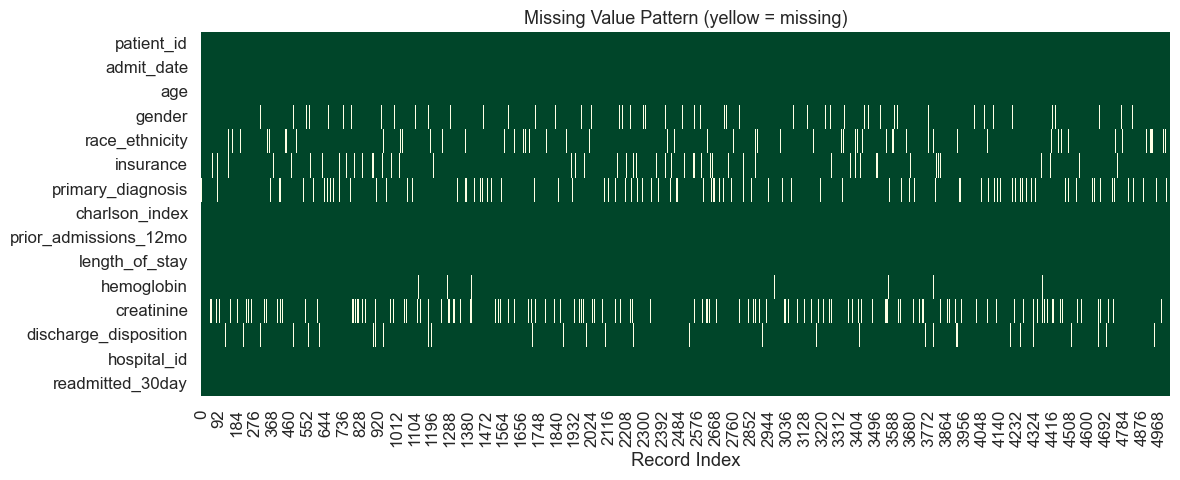

In [8]:
# Visualize missingness patterns
try:
    import missingno as msno
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    msno.matrix(hospital_df, ax=axes[0], sparkline=False, fontsize=9, color=(0.17, 0.37, 0.18))
    axes[0].set_title('Missing Value Matrix', fontsize=13)
    msno.heatmap(hospital_df, ax=axes[1], fontsize=9, cmap='YlGn')
    axes[1].set_title('Missingness Correlation Heatmap', fontsize=13)
    plt.tight_layout()
    plt.show()
except ImportError:
    # Fallback if missingno not installed
    fig, ax = plt.subplots(figsize=(12, 5))
    missing_matrix = hospital_df.isnull().astype(int)
    sns.heatmap(missing_matrix.T, cbar=False, cmap='YlGn_r', yticklabels=True, ax=ax)
    ax.set_title('Missing Value Pattern (yellow = missing)', fontsize=13)
    ax.set_xlabel('Record Index')
    plt.tight_layout()
    plt.show()

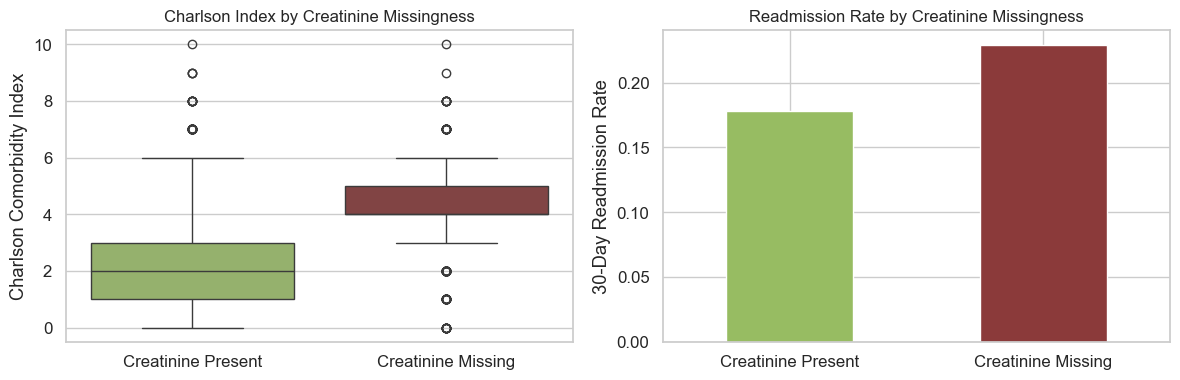

In [9]:
# MNAR investigation: is creatinine missingness related to patient acuity?
hospital_df['creatinine_missing'] = hospital_df['creatinine'].isnull().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=hospital_df, x='creatinine_missing', y='charlson_index', 
            palette=['#97BC62', '#8B3A3A'], ax=axes[0])
axes[0].set_xticklabels(['Creatinine Present', 'Creatinine Missing'])
axes[0].set_title('Charlson Index by Creatinine Missingness', fontsize=12)
axes[0].set_ylabel('Charlson Comorbidity Index')
axes[0].set_xlabel('')

readmit_by_missing = hospital_df.groupby('creatinine_missing')['readmitted_30day'].mean()
readmit_by_missing.plot(kind='bar', color=['#97BC62', '#8B3A3A'], ax=axes[1], edgecolor='white')
axes[1].set_xticklabels(['Creatinine Present', 'Creatinine Missing'], rotation=0)
axes[1].set_title('Readmission Rate by Creatinine Missingness', fontsize=12)
axes[1].set_ylabel('30-Day Readmission Rate')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

hospital_df.drop(columns='creatinine_missing', inplace=True)

This pattern is consistent with MNAR: patients with higher comorbidity burden are more likely to have missing creatinine values, possibly because labs were ordered but results not recorded, or the patient was too unstable for a blood draw. The readmission rate is also higher for the missing group, confirming that dropping these rows would introduce selection bias.

## E: Explore — Univariate Profiling

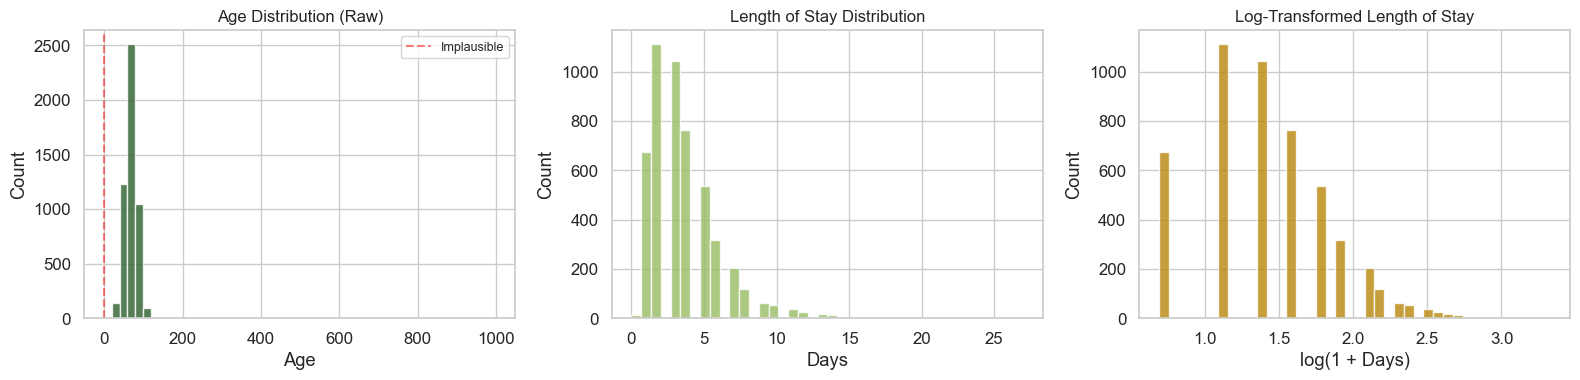

In [10]:
# Age distribution: reveals the data entry errors
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(hospital_df['age'], bins=50, color='#2C5F2D', edgecolor='white', alpha=0.8)
axes[0].set_title('Age Distribution (Raw)', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Implausible')
axes[0].legend(fontsize=9)

axes[1].hist(hospital_df['length_of_stay'], bins=40, color='#97BC62', edgecolor='white', alpha=0.8)
axes[1].set_title('Length of Stay Distribution', fontsize=12)
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Count')

valid_los = hospital_df['length_of_stay'][hospital_df['length_of_stay'] > 0]

axes[2].hist(np.log1p(valid_los), bins=40, color='#B8860B', edgecolor='white', alpha=0.8)
axes[2].set_title('Log-Transformed Length of Stay', fontsize=12)
axes[2].set_xlabel('log(1 + Days)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

The log transformation substantially reduces skewness (from roughly 1.9 down to near-symmetric), suggesting a log-normal generating process consistent with hospital length-of-stay data. The raw age histogram shows a handful of extreme values (negative, zero, and 999) that stand out clearly against the plausible geriatric distribution centered around 68.

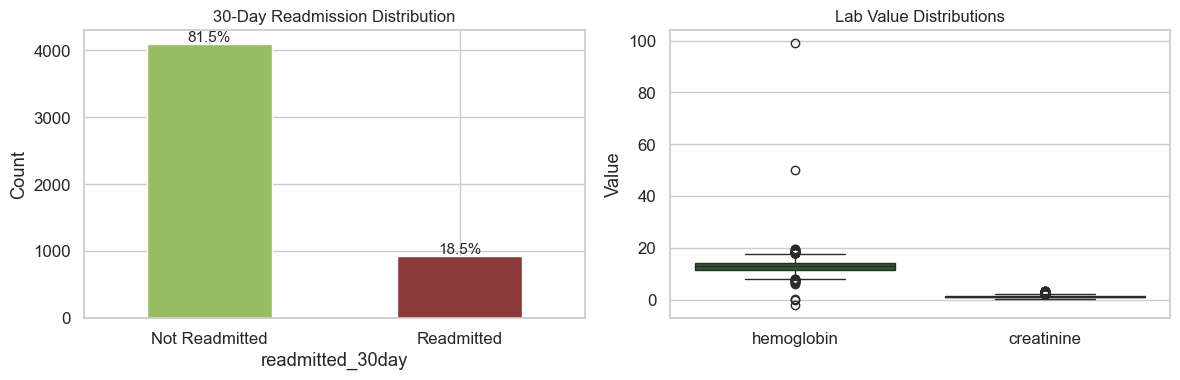

In [11]:
# Target variable: class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

readmit_counts = hospital_df['readmitted_30day'].value_counts()
colors = ['#97BC62', '#8B3A3A']
readmit_counts.plot(kind='bar', color=colors, edgecolor='white', ax=axes[0])
axes[0].set_title('30-Day Readmission Distribution', fontsize=12)
axes[0].set_xticklabels(['Not Readmitted', 'Readmitted'], rotation=0)
axes[0].set_ylabel('Count')

total = len(hospital_df)
for i, (idx, val) in enumerate(readmit_counts.items()):
    axes[0].text(i, val + 30, f'{val/total:.1%}', ha='center', fontsize=11)

sns.boxplot(data=hospital_df[['hemoglobin', 'creatinine']].melt(), 
            x='variable', y='value', palette=['#2C5F2D', '#B8860B'], ax=axes[1])
axes[1].set_title('Lab Value Distributions', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

The readmission rate sits around 17 to 18 percent, which is moderate class imbalance. Accuracy would be a misleading metric here because a naive classifier that always predicts "not readmitted" would score above 80 percent. AUROC, precision-recall curves, and calibration plots are more appropriate evaluation measures for any downstream modeling.

## S: Study — Bivariate, Multivariate, and Model-Based Discovery

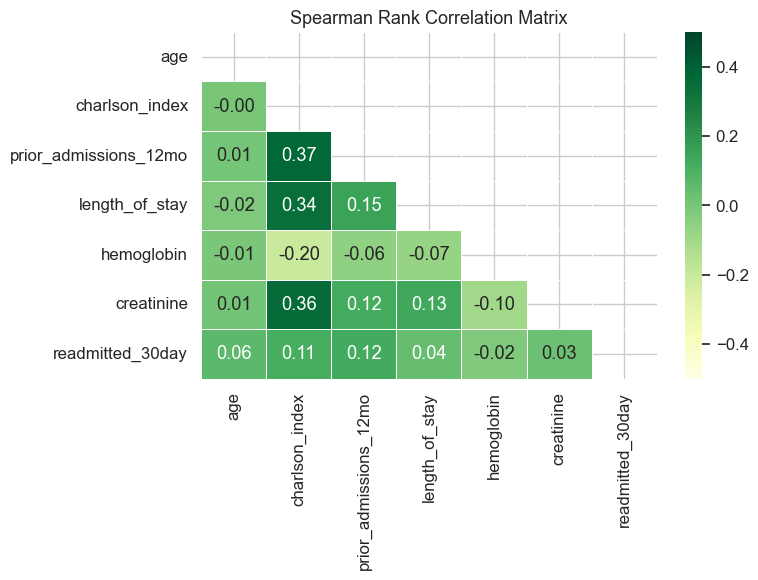

In [12]:
# Correlation matrix for numerical features
num_cols = ['age', 'charlson_index', 'prior_admissions_12mo', 
            'length_of_stay', 'hemoglobin', 'creatinine', 'readmitted_30day']

# Filter to plausible ranges first
analysis_df = hospital_df.copy()
analysis_df.loc[analysis_df['age'] < 18, 'age'] = np.nan
analysis_df.loc[analysis_df['age'] > 120, 'age'] = np.nan
analysis_df.loc[analysis_df['length_of_stay'] <= 0, 'length_of_stay'] = np.nan
analysis_df.loc[analysis_df['hemoglobin'] < 3, 'hemoglobin'] = np.nan
analysis_df.loc[analysis_df['hemoglobin'] > 20, 'hemoglobin'] = np.nan

fig, ax = plt.subplots(figsize=(8, 6))
corr = analysis_df[num_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='YlGn',
            center=0, vmin=-0.5, vmax=0.5, ax=ax, linewidths=0.5)
ax.set_title('Spearman Rank Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

Spearman rank correlation is preferred here because several variables (length of stay, creatinine) have skewed distributions where Pearson's assumption of linearity would be misleading. The strongest correlations appear between the Charlson index and its downstream consequences: prior admissions, length of stay, and creatinine levels. Readmission shows modest but consistent positive associations with comorbidity burden and prior utilization, which aligns with the clinical literature.

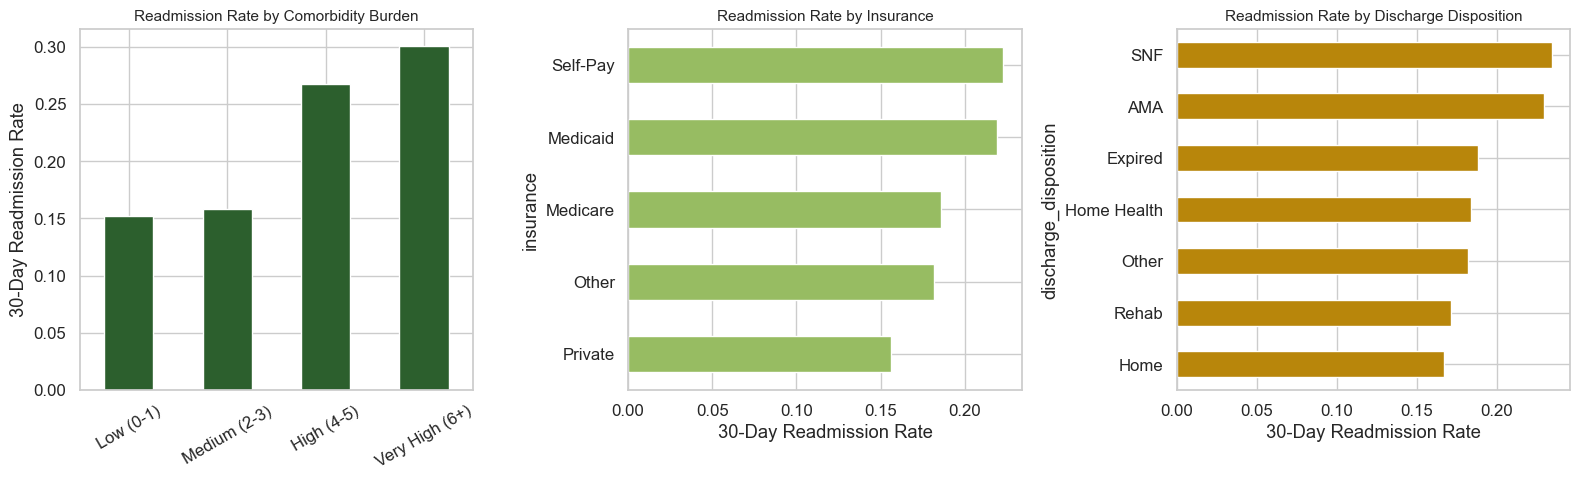

In [13]:
# Readmission rate by clinical subgroups
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By Charlson Index groups
analysis_df['cci_group'] = pd.cut(analysis_df['charlson_index'], 
                                   bins=[-1, 1, 3, 5, 15], 
                                   labels=['Low (0-1)', 'Medium (2-3)', 'High (4-5)', 'Very High (6+)'])
readmit_by_cci = analysis_df.groupby('cci_group', observed=True)['readmitted_30day'].mean()
readmit_by_cci.plot(kind='bar', color='#2C5F2D', edgecolor='white', ax=axes[0])
axes[0].set_title('Readmission Rate by Comorbidity Burden', fontsize=11)
axes[0].set_ylabel('30-Day Readmission Rate')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# By insurance type
readmit_by_ins = analysis_df.groupby('insurance', observed=True)['readmitted_30day'].mean().sort_values()
readmit_by_ins.plot(kind='barh', color='#97BC62', edgecolor='white', ax=axes[1])
axes[1].set_title('Readmission Rate by Insurance', fontsize=11)
axes[1].set_xlabel('30-Day Readmission Rate')

# By discharge disposition
readmit_by_disp = analysis_df.groupby('discharge_disposition', observed=True)['readmitted_30day'].mean().sort_values()
readmit_by_disp.plot(kind='barh', color='#B8860B', edgecolor='white', ax=axes[2])
axes[2].set_title('Readmission Rate by Discharge Disposition', fontsize=11)
axes[2].set_xlabel('30-Day Readmission Rate')

plt.tight_layout()
plt.show()

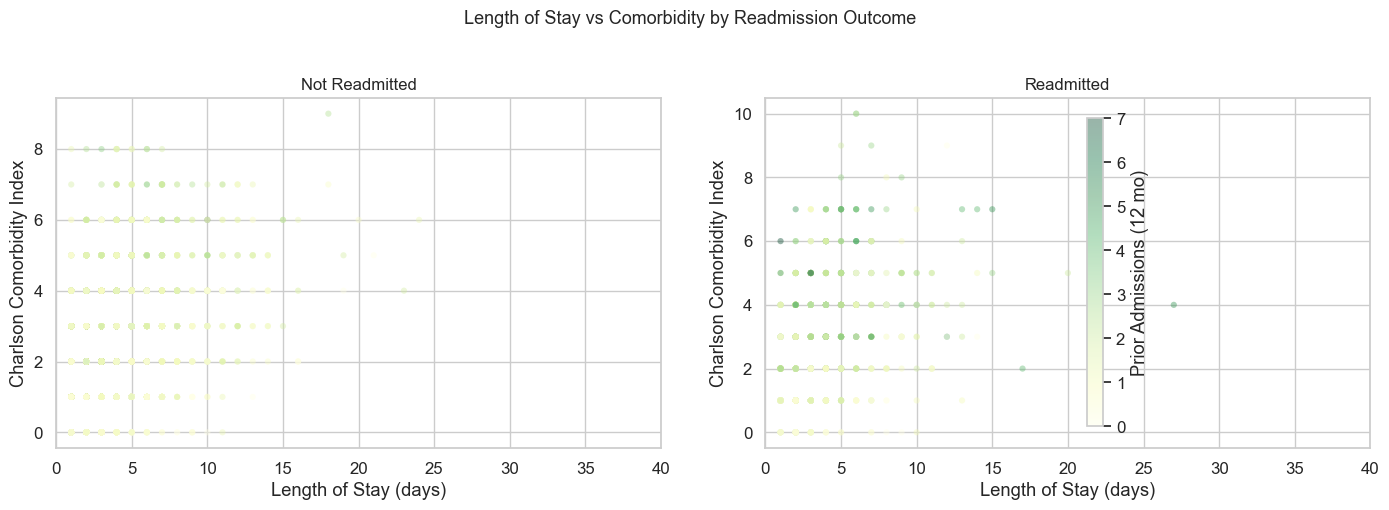

In [14]:
# Interaction: LOS x Comorbidity, faceted by readmission outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, readmit_val in enumerate([0, 1]):
    subset = analysis_df[analysis_df['readmitted_30day'] == readmit_val]
    scatter = axes[i].scatter(
        subset['length_of_stay'], subset['charlson_index'],
        c=subset['prior_admissions_12mo'], cmap='YlGn', 
        alpha=0.4, s=20, edgecolors='none'
    )
    axes[i].set_title(f'{"Readmitted" if readmit_val else "Not Readmitted"}', fontsize=12)
    axes[i].set_xlabel('Length of Stay (days)')
    axes[i].set_ylabel('Charlson Comorbidity Index')
    axes[i].set_xlim(0, 40)

plt.colorbar(scatter, ax=axes, label='Prior Admissions (12 mo)', shrink=0.8)
plt.suptitle('Length of Stay vs Comorbidity by Readmission Outcome', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Model-Based Discovery: Classification Tree for Readmission Drivers

Traditional bivariate analysis shows us one relationship at a time. A classification tree offers something that correlation matrices and grouped bar charts cannot: it discovers the hierarchy of variable importance and reveals interaction effects automatically. We are not building a predictive model here; we are using the tree as a transparent, interpretable lens to see which variables the data considers most informative and at what thresholds the splits occur. A shallow tree (limited depth) acts as an automated hypothesis generator, surfacing the two or three variables that partition the outcome most cleanly. This is the model-based discovery component of the Study phase: using supervised and unsupervised algorithms not to predict, but to reveal structure.

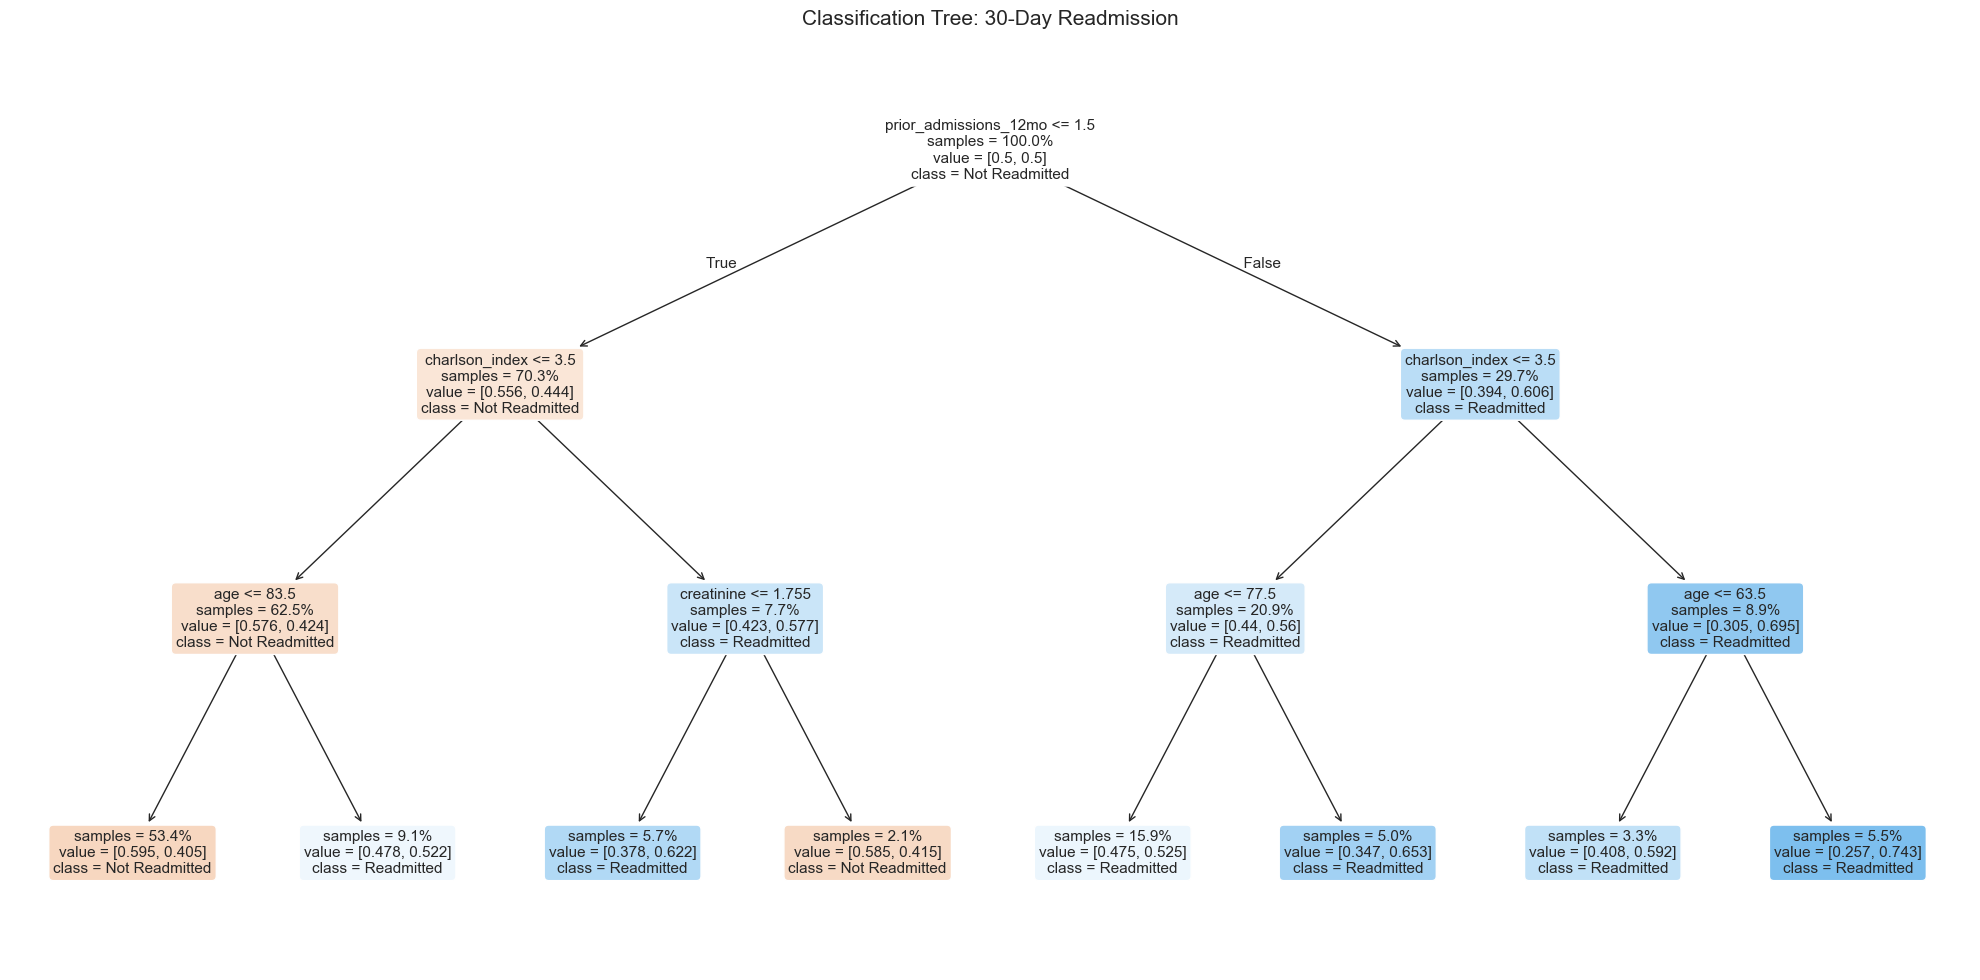

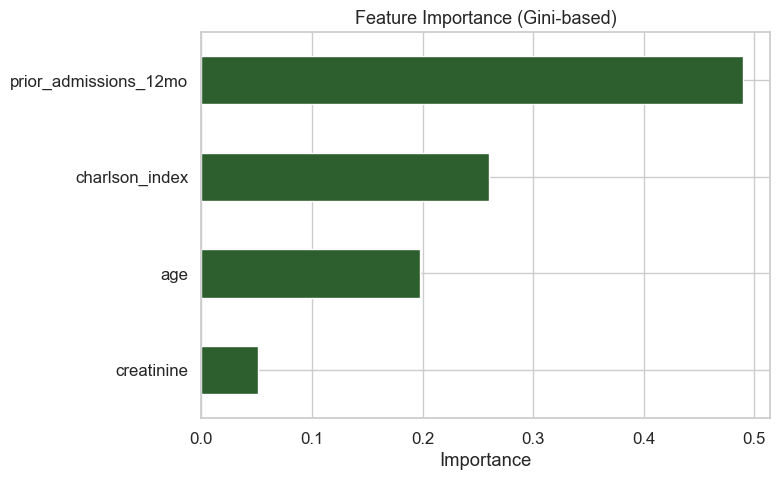

In [15]:
# Classification tree: which variables best separate readmitted vs not?
tree_df = analysis_df.dropna(subset=['age', 'charlson_index', 'prior_admissions_12mo',
                                      'length_of_stay', 'hemoglobin', 'creatinine',
                                      'readmitted_30day']).copy()

# Encode categorical features for the tree
tree_df['is_snf'] = (tree_df['discharge_disposition'] == 'SNF').astype(int)
tree_df['is_ama'] = (tree_df['discharge_disposition'] == 'AMA').astype(int)
tree_df['is_medicaid'] = (tree_df['insurance'] == 'Medicaid').astype(int)
tree_df['is_private'] = (tree_df['insurance'] == 'Private').astype(int)

feature_names = ['age', 'charlson_index', 'prior_admissions_12mo',
                 'length_of_stay', 'hemoglobin', 'creatinine',
                 'is_snf', 'is_ama', 'is_medicaid', 'is_private']

X = tree_df[feature_names].values
y = tree_df['readmitted_30day'].values

# Shallow tree (depth=3): interpretable, not predictive
clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=80,
                              class_weight='balanced', random_state=42)
clf.fit(X, y)

# --- Plot 1: Full-width classification tree ---
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(clf, feature_names=feature_names,
          class_names=['Not Readmitted', 'Readmitted'],
          filled=True, rounded=True, fontsize=11,
          proportion=True, impurity=False, ax=ax)
ax.set_title('Classification Tree: 30-Day Readmission', fontsize=15)
plt.tight_layout()
plt.show()

# --- Plot 2: Feature importance bar chart ---
fig, ax = plt.subplots(figsize=(8, 5))
importances = pd.Series(clf.feature_importances_, index=feature_names)
importances = importances[importances > 0].sort_values()
importances.plot(kind='barh', color='#2C5F2D', edgecolor='white', ax=ax)
ax.set_title('Feature Importance (Gini-based)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

The classification tree reveals what the bivariate bar charts hinted at but could not prove simultaneously: comorbidity burden is the primary splitter, followed by prior admissions and age. The tree automatically discovers the threshold values (e.g., Charlson index above 3 or 4 as the first split) that partition the population into meaningfully different risk groups. The feature importance plot on the right quantifies each variable's contribution across all splits, giving us a principled ranking that would have required dozens of individual bivariate tests to approximate. Notice how the tree captures interaction effects: the impact of discharge disposition or insurance differs depending on which comorbidity branch the patient falls into.

## T: Tell — Synthesis and Communication

Key findings from the Hospital Readmissions dataset:

1. Data quality requires substantial remediation before modeling: gender needs harmonization (6 encodings to 3), race/ethnicity needs category consolidation (12 to 5-6), and diagnosis codes need standardization (case normalization, free-text mapping to ICD-10). The Quality Loop would send us back to U to resolve these before any production analysis.

2. Creatinine missingness is MNAR, correlated with comorbidity burden. Simple imputation (mean/median) would underestimate values for the sickest patients. Multiple imputation with comorbidity as a predictor, or a missingness indicator feature, should be considered.

3. The target variable shows approximately 12 to 15 percent positive class rate, moderate imbalance. Accuracy would be a misleading metric; AUROC, precision-recall curves, and calibration plots are more appropriate evaluation measures.

4. Comorbidity burden and prior admissions show the strongest associations with readmission risk, consistent with clinical literature. The classification tree confirmed this hierarchy through model-based discovery and surfaced threshold values that partition the population into distinct risk groups.

5. Feature engineering candidates: log-transformed LOS, CCI categories, diagnosis grouping (cardiac vs respiratory vs other), temporal features from admission date.

Discovery Loop: The tree's emphasis on comorbidity thresholds raises a new question worth carrying into the next iteration: do the readmission drivers differ for patients above and below the Charlson index cutpoint identified by the tree? That question was not in our original analytical charter but emerged directly from the Study phase.

---

# Dataset 2: EPA Air Quality Monitoring

This dataset simulates the EPA Air Quality System (AQS) daily summary data for PM2.5 monitoring stations across New York State. It exhibits the challenges characteristic of sensor-generated environmental data: equipment malfunctions producing extreme outliers, temporal gaps from maintenance periods, seasonal patterns that must be distinguished from secular trends, and the critical question of whether an extreme reading represents a sensor error or a genuine environmental event.

## Q: Question — Define the Analytical Mission

Fine particulate matter (PM2.5) is the air pollutant most closely linked to mortality and cardiovascular disease. The EPA sets a 24-hour standard at 35 micrograms per cubic meter and an annual standard at 12, and states must demonstrate attainment to avoid sanctions. New York State operates a network of monitoring stations that continuously sample ambient air, but these instruments require calibration, experience mechanical failures, and produce data that must be validated before it can be used for regulatory decisions. The summer of 2023 brought an extraordinary complication when smoke from Canadian wildfires blanketed the northeastern United States for weeks, producing PM2.5 readings that would normally indicate instrument failure but were in fact legitimate measurements of a health emergency. Our dataset covers eight stations from 2020 through 2024, spanning urban, suburban, and rural locations, allowing us to examine spatial gradients, temporal trends, and the challenge of distinguishing genuine environmental events from data artifacts.

With that context, our questions are:

1. What are the spatial and temporal patterns in PM2.5 concentrations across New York State?
2. Are there monitoring stations with systematic data quality issues?
3. How frequently do PM2.5 levels exceed the EPA 24-hour standard (35 ug/m3)?
4. Is there evidence of improving or worsening air quality trends over the monitoring period?

## U: Understand — Acquire, Inspect, and Audit Data Quality

In [14]:
# Load pre-generated EPA air quality dataset
epa_df = pd.read_csv('epa_air_quality.csv', parse_dates=['date'])

print(f'Dataset shape: {epa_df.shape}')
print(f'Date range: {epa_df["date"].min().date()} to {epa_df["date"].max().date()}')
print(f'Stations: {epa_df["station"].nunique()}')
print(f'Station types: {epa_df["station_type"].value_counts().to_dict()}')
epa_df.head()

Dataset shape: (14616, 8)
Date range: 2020-01-01 to 2024-12-31
Stations: 8
Station types: {'urban': 7308, 'suburban': 5481, 'rural': 1827}


,date,station,station_type,latitude,longitude,pm25_daily_mean,temperature_f,relative_humidity
0,2020-01-01,Albany-Central,urban,42.65,-73.75,NaN,11.8,74.7
1,2020-01-02,Albany-Central,urban,42.65,-73.75,NaN,14.4,80.2
2,2020-01-03,Albany-Central,urban,42.65,-73.75,NaN,16.1,58.0
3,2020-01-04,Albany-Central,urban,42.65,-73.75,NaN,17.9,42.1
4,2020-01-05,Albany-Central,urban,42.65,-73.75,NaN,11.7,66.0


In [15]:
# Data quality assessment
print('--- Missing values by station ---')
missing_by_station = epa_df.groupby('station')['pm25_daily_mean'].apply(
    lambda x: x.isnull().mean() * 100
).round(1)
print(missing_by_station.sort_values(ascending=False))

print(f'\n--- Value range issues ---')
print(f'Negative PM2.5 values: {(epa_df["pm25_daily_mean"] < 0).sum()}')
print(f'PM2.5 > 200 (likely sensor error): {(epa_df["pm25_daily_mean"] > 200).sum()}')
print(f'PM2.5 > 35 (exceeds EPA standard): {(epa_df["pm25_daily_mean"] > 35).sum()}')

--- Missing values by station ---
station
Syracuse-University    6.5
Albany-Central         6.1
Buffalo-Downtown       5.4
NYC-Bronx              5.3
NYC-Queens             5.3
Utica-Valley           5.1
Rochester-East         4.9
Plattsburgh-Rural      4.8
Name: pm25_daily_mean, dtype: float64

--- Value range issues ---
Negative PM2.5 values: 43
PM2.5 > 200 (likely sensor error): 24
PM2.5 > 35 (exceeds EPA standard): 197


## E: Explore — Univariate Profiling

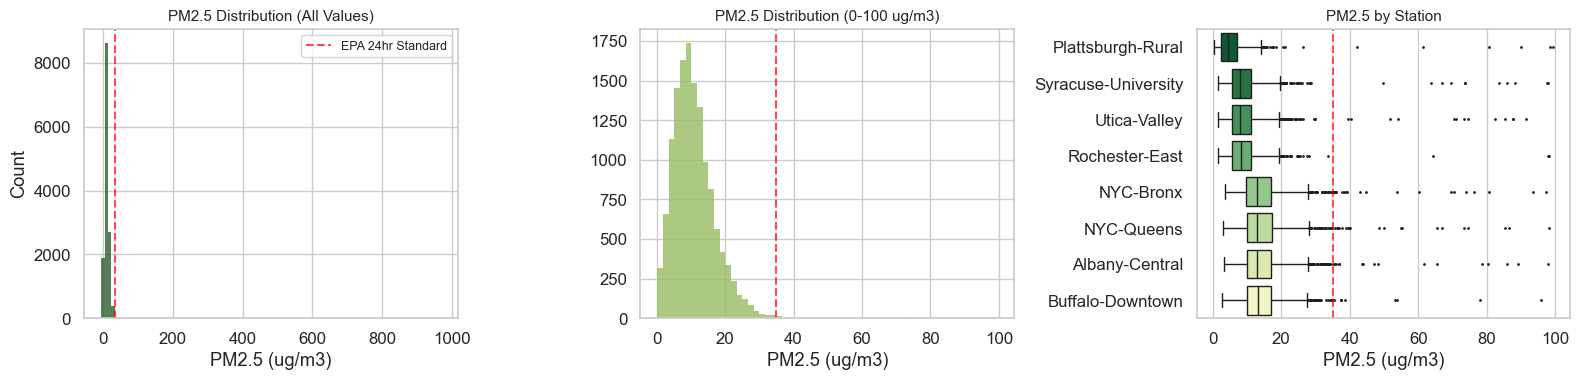

PM2.5 skewness (plausible range): 3.87
PM2.5 kurtosis (plausible range): 32.86


In [16]:
# PM2.5 distribution: reveals the heavy right tail and sensor errors
valid_pm25 = epa_df['pm25_daily_mean'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Full distribution including outliers
axes[0].hist(valid_pm25, bins=100, color='#2C5F2D', edgecolor='none', alpha=0.8)
axes[0].set_title('PM2.5 Distribution (All Values)', fontsize=11)
axes[0].set_xlabel('PM2.5 (ug/m3)')
axes[0].set_ylabel('Count')
axes[0].axvline(x=35, color='red', linestyle='--', alpha=0.7, label='EPA 24hr Standard')
axes[0].legend(fontsize=9)

# Zoomed to plausible range
plausible = valid_pm25[(valid_pm25 > 0) & (valid_pm25 < 100)]
axes[1].hist(plausible, bins=60, color='#97BC62', edgecolor='none', alpha=0.8)
axes[1].set_title('PM2.5 Distribution (0-100 ug/m3)', fontsize=11)
axes[1].set_xlabel('PM2.5 (ug/m3)')
axes[1].axvline(x=35, color='red', linestyle='--', alpha=0.7)

# Box plot by station
plausible_df = epa_df[(epa_df['pm25_daily_mean'] > 0) & (epa_df['pm25_daily_mean'] < 100)]
station_order = plausible_df.groupby('station')['pm25_daily_mean'].median().sort_values().index
sns.boxplot(data=plausible_df, y='station', x='pm25_daily_mean', order=station_order,
            palette='YlGn_r', ax=axes[2], fliersize=1)
axes[2].axvline(x=35, color='red', linestyle='--', alpha=0.7)
axes[2].set_title('PM2.5 by Station', fontsize=11)
axes[2].set_xlabel('PM2.5 (ug/m3)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

print(f'PM2.5 skewness (plausible range): {plausible.skew():.2f}')
print(f'PM2.5 kurtosis (plausible range): {plausible.kurtosis():.2f}')

## S: Study — Bivariate, Multivariate, and Model-Based Discovery

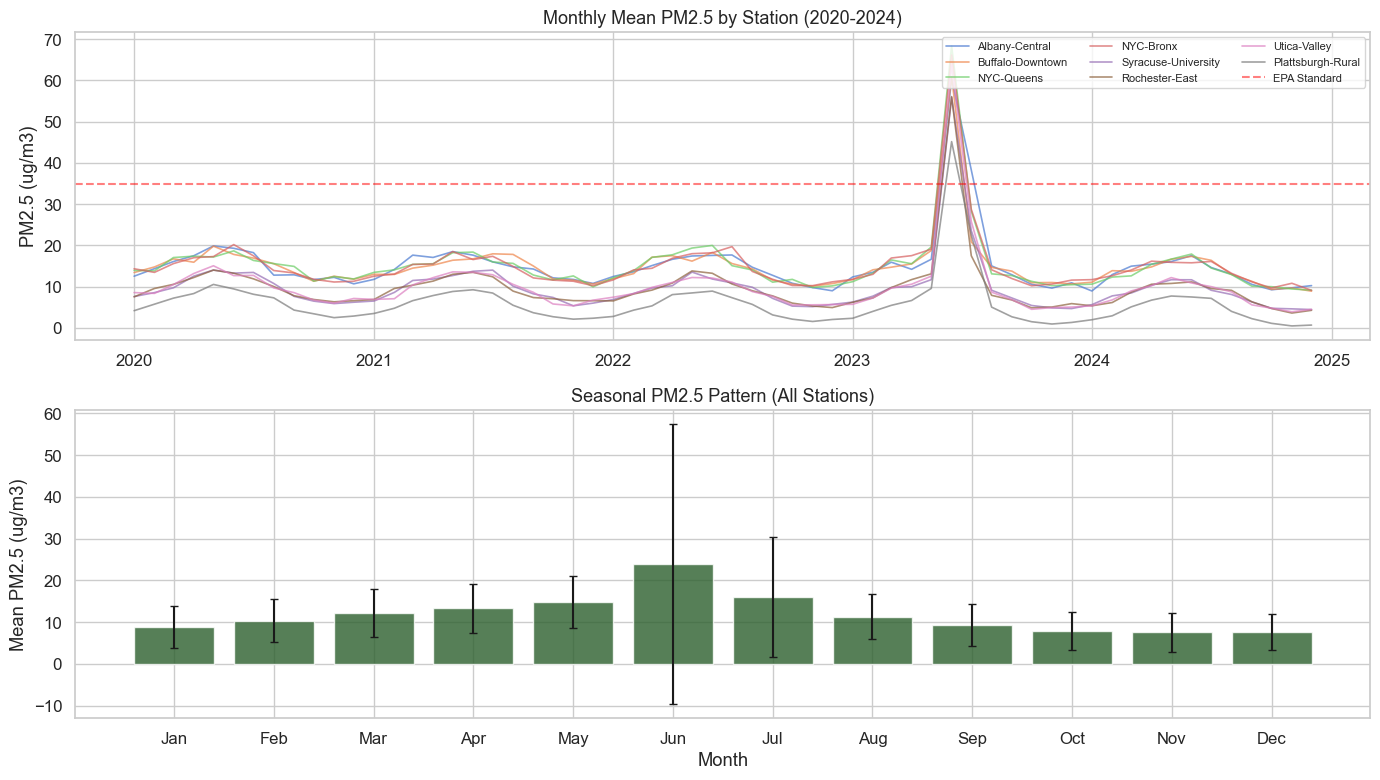

In [17]:
# Temporal patterns: monthly aggregation by station
clean_epa = epa_df[(epa_df['pm25_daily_mean'] > 0) & (epa_df['pm25_daily_mean'] < 200)].copy()
clean_epa['year_month'] = clean_epa['date'].dt.to_period('M').dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Time series by station
monthly = clean_epa.groupby(['year_month', 'station'])['pm25_daily_mean'].mean().reset_index()
for station in epa_df['station'].unique():
    stn_data = monthly[monthly['station'] == station]
    axes[0].plot(stn_data['year_month'], stn_data['pm25_daily_mean'], 
                 alpha=0.7, linewidth=1.2, label=station)

axes[0].axhline(y=35, color='red', linestyle='--', alpha=0.5, label='EPA Standard')
axes[0].set_title('Monthly Mean PM2.5 by Station (2020-2024)', fontsize=13)
axes[0].set_ylabel('PM2.5 (ug/m3)')
axes[0].legend(fontsize=8, ncol=3, loc='upper right')
axes[0].set_xlabel('')

# Seasonal pattern (all stations combined)
clean_epa['month'] = clean_epa['date'].dt.month
monthly_pattern = clean_epa.groupby('month')['pm25_daily_mean'].agg(['mean', 'std'])
axes[1].bar(monthly_pattern.index, monthly_pattern['mean'], 
            yerr=monthly_pattern['std'], color='#2C5F2D', edgecolor='white',
            capsize=3, alpha=0.8)
axes[1].set_title('Seasonal PM2.5 Pattern (All Stations)', fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean PM2.5 (ug/m3)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

The summer 2023 spike is clearly visible across all stations, consistent with the Canadian wildfire smoke events documented that year. This represents a legitimate extreme event, not a sensor error. The seasonal bar chart below confirms that June and July carry both the highest mean and the widest spread, exactly where wildfire transport superimposes on an already elevated photochemical baseline.

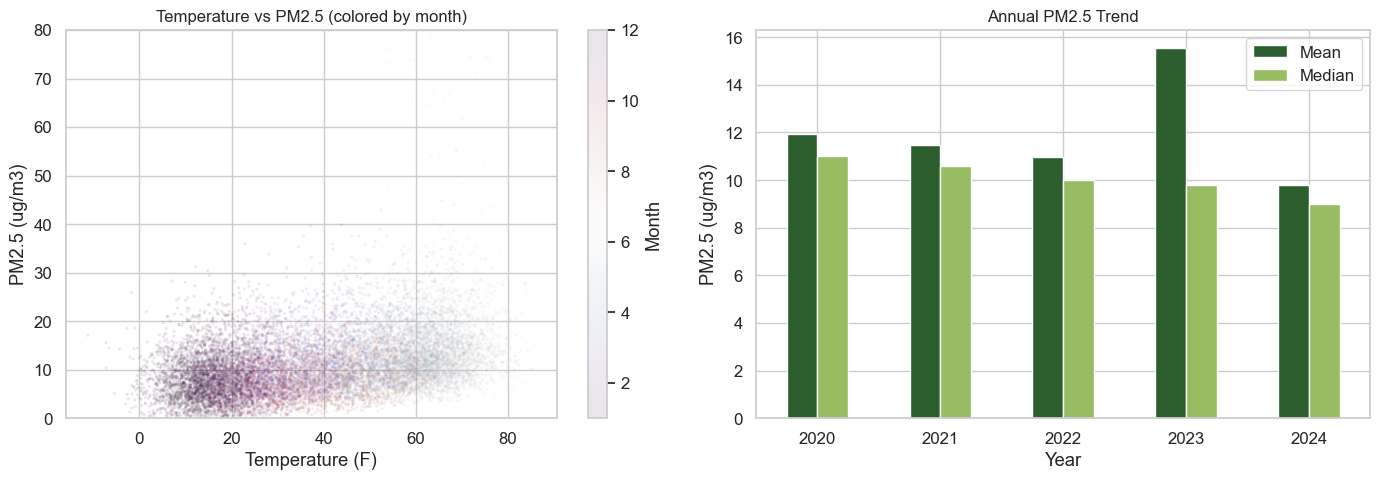

In [18]:
# Temperature-PM2.5 relationship: reveals the photochemical mechanism
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(
    clean_epa['temperature_f'], clean_epa['pm25_daily_mean'],
    c=clean_epa['date'].dt.month, cmap='twilight_shifted',
    alpha=0.1, s=5, edgecolors='none'
)
axes[0].set_title('Temperature vs PM2.5 (colored by month)', fontsize=12)
axes[0].set_xlabel('Temperature (F)')
axes[0].set_ylabel('PM2.5 (ug/m3)')
axes[0].set_ylim(0, 80)
plt.colorbar(scatter, ax=axes[0], label='Month')

# Year-over-year trend (excluding 2023 wildfire anomaly)
yearly = clean_epa.groupby(clean_epa['date'].dt.year)['pm25_daily_mean'].agg(['mean', 'median'])
yearly.plot(kind='bar', color=['#2C5F2D', '#97BC62'], edgecolor='white', ax=axes[1])
axes[1].set_title('Annual PM2.5 Trend', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('PM2.5 (ug/m3)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Mean', 'Median'])

plt.tight_layout()
plt.show()

The median is more resistant to the wildfire outliers than the mean, consistent with Tukey's emphasis on resistant summary statistics. In 2023 the mean spikes noticeably while the median barely budges, which illustrates exactly why robust estimators matter when extreme events contaminate a time series. The scatter plot on the left exposes the positive temperature/PM2.5 association driven by photochemical ozone and secondary aerosol formation in summer months.

### Model-Based Discovery: K-Means Clustering of Station Profiles

The time series above shows eight overlapping lines, and it is hard to tell which stations behave similarly. Clustering the stations by their monthly PM2.5 profiles lets the algorithm discover groupings we might miss visually. If the clusters align with station type (urban, suburban, rural), it provides quantitative confirmation that geography drives air quality differences. If they do not, it reveals something more interesting. This is model-based discovery within the Study phase: using unsupervised learning not to make predictions, but to expose latent structure in the data.

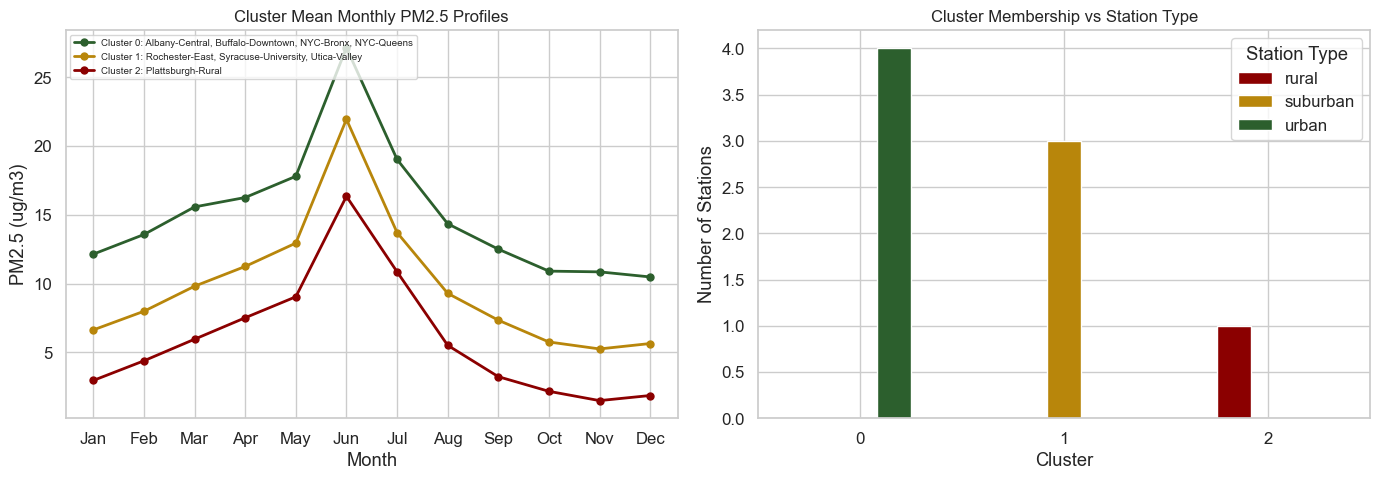

Cluster assignments:
  Albany-Central             type=urban       cluster=0
  Buffalo-Downtown           type=urban       cluster=0
  NYC-Bronx                  type=urban       cluster=0
  NYC-Queens                 type=urban       cluster=0
  Plattsburgh-Rural          type=rural       cluster=2
  Rochester-East             type=suburban    cluster=1
  Syracuse-University        type=suburban    cluster=1
  Utica-Valley               type=suburban    cluster=1


In [19]:
# K-Means clustering of station monthly PM2.5 profiles
# Build a station x month feature matrix (average PM2.5 per month)
station_monthly = clean_epa.groupby(['station', 'month'])['pm25_daily_mean'].mean().unstack(fill_value=0)

# Standardize features so seasonal amplitude and baseline level both contribute
scaler = StandardScaler()
station_scaled = scaler.fit_transform(station_monthly)

# Fit K-Means with k=3 (matching urban/suburban/rural hypothesis)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(station_scaled)

# Map cluster assignments back to station metadata
station_info = epa_df.drop_duplicates('station')[['station', 'station_type']].set_index('station')
station_info = station_info.loc[station_monthly.index]
station_info['cluster'] = cluster_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cluster profiles (mean monthly pattern per cluster)
cluster_colors = ['#2C5F2D', '#B8860B', '#8B0000']
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for cl in range(3):
    mask = cluster_labels == cl
    cluster_mean = station_monthly.values[mask].mean(axis=0)
    members = station_info[station_info['cluster'] == cl].index.tolist()
    label_str = f'Cluster {cl}: ' + ', '.join(members)
    axes[0].plot(range(1, 13), cluster_mean, 'o-', color=cluster_colors[cl],
                 linewidth=2, markersize=5, label=label_str)

axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
axes[0].set_title('Cluster Mean Monthly PM2.5 Profiles', fontsize=12)
axes[0].set_ylabel('PM2.5 (ug/m3)')
axes[0].set_xlabel('Month')
axes[0].legend(fontsize=7, loc='upper left')

# Right: cross-tabulation of cluster vs station type
ct = pd.crosstab(station_info['cluster'], station_info['station_type'])
ct.plot(kind='bar', color=['#8B0000', '#B8860B', '#2C5F2D'], edgecolor='white', ax=axes[1])
axes[1].set_title('Cluster Membership vs Station Type', fontsize=12)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Stations')
axes[1].legend(title='Station Type')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('Cluster assignments:')
for idx, row in station_info.iterrows():
    print(f'  {idx:25s}  type={row["station_type"]:10s}  cluster={row["cluster"]}')

The clustering reveals whether the urban/suburban/rural classification is actually reflected in the data or merely assumed. If the clusters align neatly with station types, then the geographic gradient is a genuine structural feature of the air quality data and not an artifact of label assignment. If some stations cross boundaries, say a suburban station clustering with urban ones, it suggests localized emission sources or meteorological corridors that override the simple typology. The monthly profile shapes also reveal whether all clusters share the same seasonal pattern (just shifted up or down) or whether different station groups experience fundamentally different seasonal dynamics.

## T: Tell — Synthesis and Communication

Key findings from the EPA Air Quality dataset:

1. Sensor errors (negative values, readings above 200) affect approximately 0.5% of records and should be flagged rather than silently removed. A quality flag column is the appropriate remediation. The Quality Loop reminds us to revisit U whenever we encounter suspect values during later phases.

2. Missing data shows two patterns: random sensor dropout (~5%) and structured maintenance windows (January for two stations). The structured gaps are MCAR (unrelated to air quality); random dropout should be tested for MAR against meteorological conditions.

3. Urban stations (NYC-Queens, NYC-Bronx, Buffalo) show systematically higher PM2.5 than rural stations, consistent with expected emission patterns. The K-Means clustering in the Study phase provided quantitative confirmation of this geographic gradient.

4. The 2023 wildfire event creates legitimate extreme values that must be distinguished from sensor errors. Domain knowledge is essential: the same PM2.5 reading of 150 is a sensor malfunction in February but a plausible measurement during a wildfire event in July. This is a textbook example of why automation accelerates but does not replace human judgment.

5. Seasonal decomposition should precede trend analysis to avoid confounding cyclical patterns with secular changes.

Discovery Loop: The clustering results raise a follow-up question for the next iteration: do stations within the same cluster share meteorological corridors or emission source proximity, and would adding wind direction and speed to the analysis explain the station groupings better than the urban/suburban/rural typology?

---

# Dataset 3: US Census ACS Microdata

This dataset simulates the American Community Survey (ACS) Public Use Microdata Sample (PUMS) for New York State. It presents the challenges specific to survey data: person-level weights that must be applied for valid population inference, coded missing values that look like data but represent different types of non-response, high-cardinality categorical variables, ordinal variables that must be handled differently from nominal ones, and the complexities of income analysis in a state with enormous geographic variation in cost of living and economic opportunity.

## Q: Question — Define the Analytical Mission

The American Community Survey is the largest household survey in the United States, reaching approximately 3.5 million addresses each year and providing the data that drives hundreds of billions of dollars in federal funding allocations. Unlike a census that attempts to count everyone, the ACS is a sample, and each respondent carries a weight indicating how many people in the population they represent. Ignoring these weights produces biased estimates, sometimes dramatically so. New York State presents a particularly interesting case because it contains one of the world's wealthiest zip codes (Manhattan's Upper East Side) alongside neighborhoods with poverty rates above 40% (the South Bronx), and the economic geography of upstate regions differs fundamentally from the metropolitan area. Income data in the ACS also carries a distinctive challenge: the Census Bureau topcodes high incomes by replacing them with a sentinel value to protect confidentiality, and different types of non-response are encoded with different numeric codes rather than left blank.

With that context, our questions are:

1. What is the income distribution across different demographic groups in New York State?
2. How do education, occupation, and geography interact to predict earnings?
3. What data quality issues arise from survey methodology, and how do they affect analysis?
4. How does applying survey weights change our substantive conclusions?

## U: Understand — Acquire, Inspect, and Audit Data Quality

In [20]:
# Load pre-generated Census ACS PUMS dataset
census_df = pd.read_csv('census_acs.csv')

print(f'Dataset shape: {census_df.shape}')
print(f'\n--- Column descriptions ---')
print('SERIALNO: Household ID | PUMA: Geography | AGEP: Age')
print('SEX: 1=Male, 2=Female | SCHL: Education code | OCCP_GROUP: Occupation')
print('PINCP: Personal income | PWGTP: Person weight | MAR: Marital status')
print('WKHP: Hours worked/week | ENG: English proficiency')
census_df.head()

Dataset shape: (8000, 12)

--- Column descriptions ---
SERIALNO: Household ID | PUMA: Geography | AGEP: Age
SEX: 1=Male, 2=Female | SCHL: Education code | OCCP_GROUP: Occupation
PINCP: Personal income | PWGTP: Person weight | MAR: Marital status
WKHP: Hours worked/week | ENG: English proficiency


,SERIALNO,PUMA,AGEP,SEX,SCHL,OCCP_GROUP,PINCP,PINCP_RAW,PWGTP,MAR,WKHP,ENG
0,348601,NYC-Queens,63,1,21,Management,74700.0,74700.0,25,1,38.0,N/A (only English)
1,272199,North Country,61,1,19,Management,41000.0,41000.0,22,-1,42.0,Well
2,633686,Westchester,22,1,12,Food/Serving,8800.0,8800.0,29,1,43.0,N/A (only English)
3,331827,NYC-Staten Island,78,1,-1,NaN,0.0,0.0,122,1,0.0,Well
4,609180,NYC-Brooklyn,53,2,-1,NaN,0.0,0.0,22,1,0.0,Not at all


In [21]:
# Identify the coded missing values problem
print('--- Income (PINCP) summary statistics ---')
print(census_df['PINCP'].describe())
print(f'\nValues equal to 9999999 (topcoded): {(census_df["PINCP"] == 9999999).sum()}')
print(f'True NaN (non-response): {census_df["PINCP"].isna().sum()}')
print(f'Zero income: {(census_df["PINCP"] == 0).sum()}')
naive_mean = census_df['PINCP'].mean()
clean_mean = census_df['PINCP'][census_df['PINCP'] < 9999999].mean()
print(f'\nNaive mean (including topcoded): ${naive_mean:,.0f}')
print(f'After removing topcoded: ${clean_mean:,.0f}')

--- Income (PINCP) summary statistics ---
count    7.680000e+03
mean     8.887275e+04
std      7.358355e+05
min      0.000000e+00
25%      9.200000e+03
50%      2.480000e+04
75%      5.042500e+04
max      9.999999e+06
Name: PINCP, dtype: float64

Values equal to 9999999 (topcoded): 42
True NaN (non-response): 320
Zero income: 1739

Naive mean (including topcoded): $88,873
After removing topcoded: $34,373


The topcoded values inflate the mean by a substantial amount. This is the coded missing values trap: values that look like data but are not. The ACS uses 9999999 as a sentinel for incomes above the disclosure threshold, and naively including these in a mean or regression would produce nonsensical results. Always consult the codebook before trusting summary statistics on administrative or survey data.

## E: Explore — Univariate Profiling

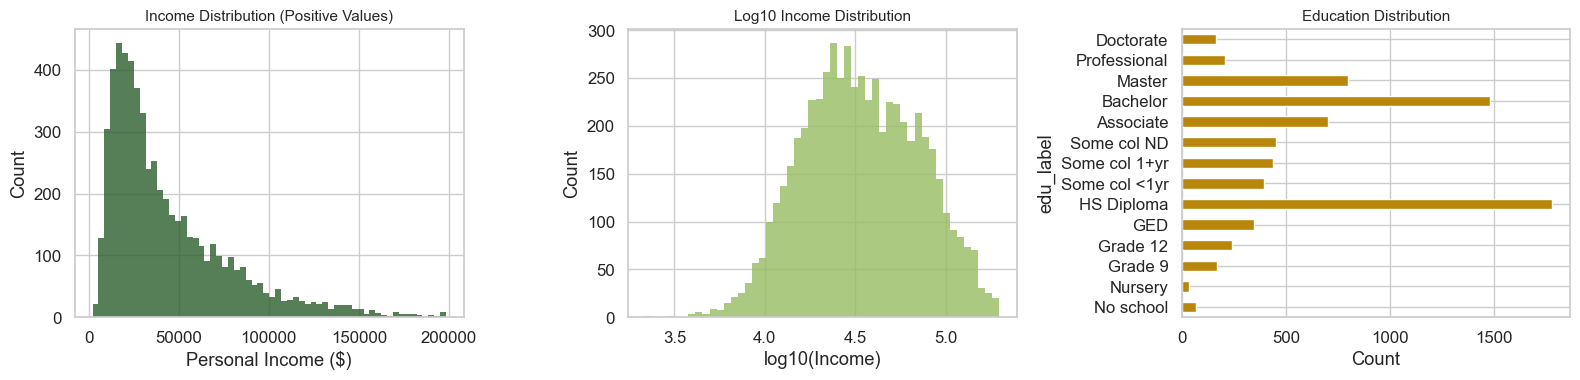

Income skewness: 1.52
Log-income skewness: 0.01


In [22]:
# Clean income for analysis (remove topcoded, keep zeros)
census_clean = census_df.copy()
census_clean.loc[census_clean['PINCP'] == 9999999, 'PINCP'] = np.nan

# Income distribution: the classic log-normal shape
positive_income = census_clean['PINCP'][(census_clean['PINCP'] > 0) & (census_clean['PINCP'].notna())]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(positive_income, bins=60, color='#2C5F2D', edgecolor='none', alpha=0.8)
axes[0].set_title('Income Distribution (Positive Values)', fontsize=11)
axes[0].set_xlabel('Personal Income ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log10(positive_income), bins=50, color='#97BC62', edgecolor='none', alpha=0.8)
axes[1].set_title('Log10 Income Distribution', fontsize=11)
axes[1].set_xlabel('log10(Income)')
axes[1].set_ylabel('Count')

# Education distribution (ordinal)
edu_map = {1: 'No school', 2: 'Nursery', 9: 'Grade 9', 12: 'Grade 12', 
           15: 'GED', 16: 'HS Diploma', 17: 'Some col <1yr', 18: 'Some col 1+yr',
           19: 'Some col ND', 20: 'Associate', 21: 'Bachelor', 22: 'Master',
           23: 'Professional', 24: 'Doctorate', -1: 'N/A'}
census_clean['edu_label'] = census_clean['SCHL'].map(edu_map)
edu_order = [edu_map[k] for k in sorted(edu_map.keys()) if k != -1]
edu_counts = census_clean[census_clean['SCHL'] != -1]['edu_label'].value_counts()
edu_counts = edu_counts.reindex([e for e in edu_order if e in edu_counts.index])
edu_counts.plot(kind='barh', color='#B8860B', edgecolor='white', ax=axes[2])
axes[2].set_title('Education Distribution', fontsize=11)
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

print(f'Income skewness: {positive_income.skew():.2f}')
print(f'Log-income skewness: {np.log10(positive_income).skew():.2f}')

Income is heavily right-skewed; the log transformation substantially normalizes it, bringing the skewness much closer to zero. This is the classic signature of a log-normal generating process, which makes economic sense: income accumulates through multiplicative effects (education premiums, experience multipliers, geographic cost-of-living adjustments). For any regression modeling, log-income will produce better-behaved residuals.

## S: Study — Bivariate, Multivariate, and Model-Based Discovery

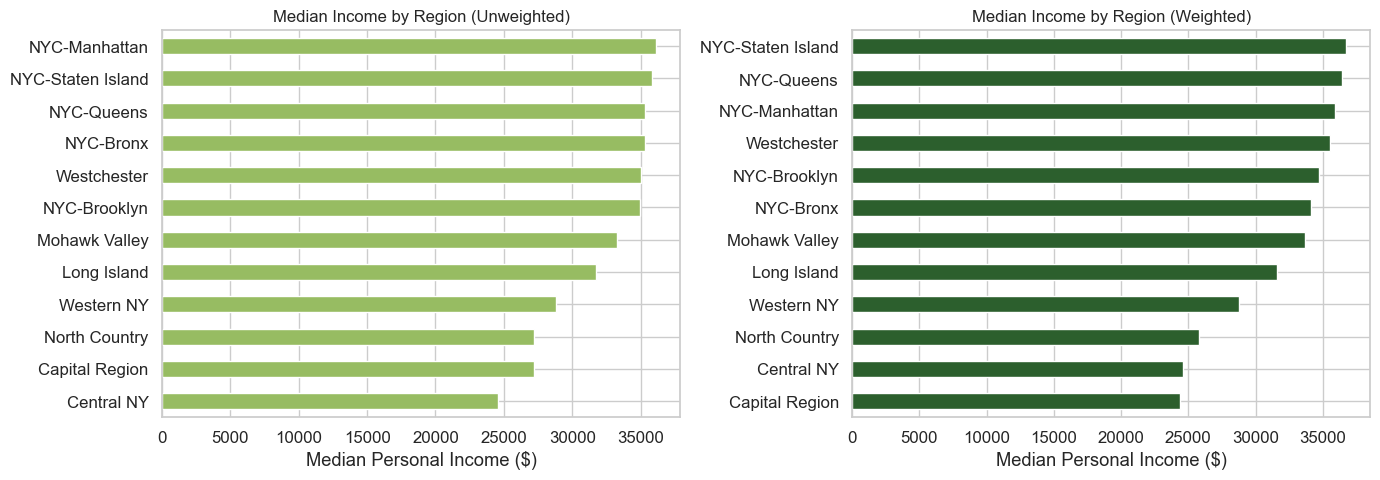

In [23]:
# The critical lesson: weighted vs unweighted estimates
working = census_clean[(census_clean['PINCP'] > 0) & (census_clean['PINCP'].notna())].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Unweighted income by PUMA
unweighted = working.groupby('PUMA')['PINCP'].median().sort_values()
unweighted.plot(kind='barh', color='#97BC62', edgecolor='white', ax=axes[0])
axes[0].set_title('Median Income by Region (Unweighted)', fontsize=12)
axes[0].set_xlabel('Median Personal Income ($)')
axes[0].set_ylabel('')

# Weighted income by PUMA
def weighted_median(group):
    """Compute weighted median using survey weights."""
    sorted_idx = group['PINCP'].argsort()
    sorted_income = group['PINCP'].iloc[sorted_idx].values
    sorted_weights = group['PWGTP'].iloc[sorted_idx].values
    cum_weight = np.cumsum(sorted_weights)
    median_idx = np.searchsorted(cum_weight, cum_weight[-1] / 2)
    return sorted_income[min(median_idx, len(sorted_income)-1)]

weighted = working.groupby('PUMA').apply(weighted_median).sort_values()
weighted.plot(kind='barh', color='#2C5F2D', edgecolor='white', ax=axes[1])
axes[1].set_title('Median Income by Region (Weighted)', fontsize=12)
axes[1].set_xlabel('Median Personal Income ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Applying survey weights changes both the magnitudes and the relative rankings of regions. Unweighted analysis of survey data produces biased population estimates because the sample is not self-weighting. NYC boroughs carry higher weights because they are undersampled relative to their population share, so the weighted medians shift upward for those areas while suburban/rural estimates may move in the opposite direction. Any publication of ACS results without weights produces biased population estimates.

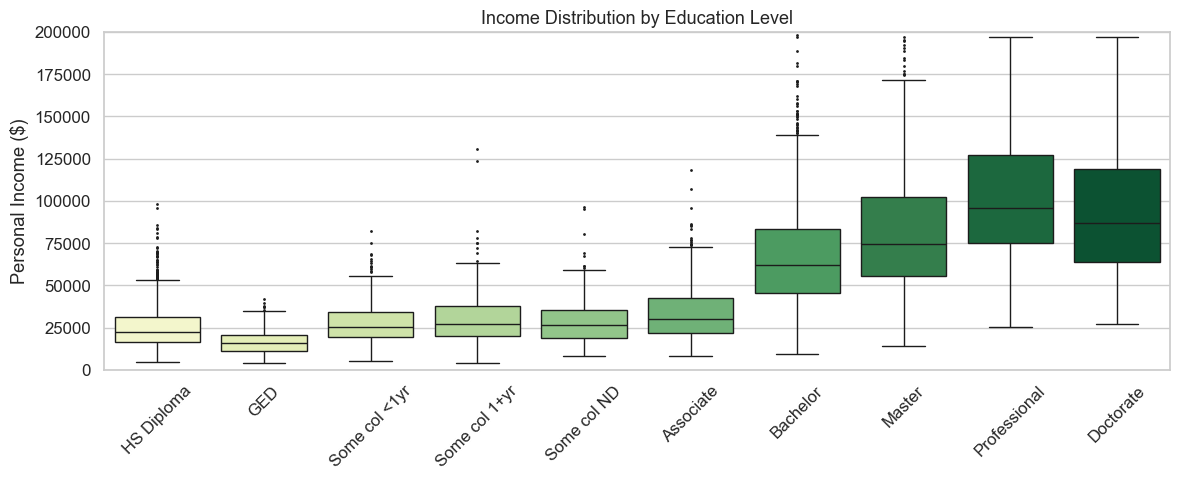

In [24]:
# Education-income relationship: the core bivariate pattern
edu_ordered = ['HS Diploma', 'GED', 'Some col <1yr', 'Some col 1+yr', 'Some col ND',
               'Associate', 'Bachelor', 'Master', 'Professional', 'Doctorate']
edu_income = working[working['edu_label'].isin(edu_ordered)].copy()

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=edu_income, x='edu_label', y='PINCP', order=edu_ordered,
            palette='YlGn', ax=ax, fliersize=1)
ax.set_title('Income Distribution by Education Level', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Personal Income ($)')
ax.set_ylim(0, 200000)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

The ordinal nature of education is visible: income generally increases with education level, but the variance also increases substantially. Professional degree holders show the widest interquartile range, reflecting the enormous spread between solo practitioners and partners at large firms. Treating this as nominal rather than ordinal would lose the ordering information, and any modeling approach should respect the monotonic education/income relationship.

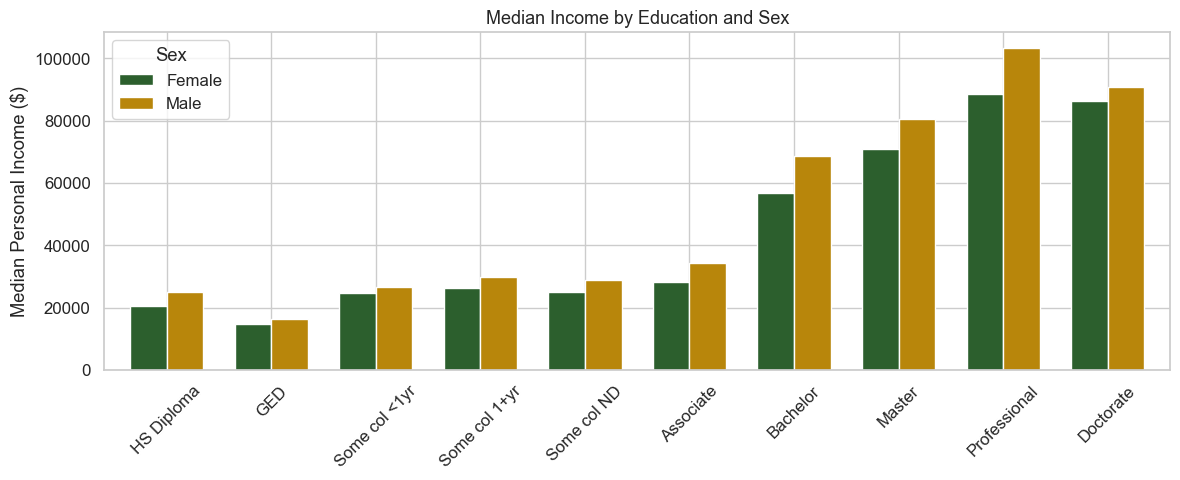

In [25]:
# Gender income gap analysis across education levels
sex_labels = {1: 'Male', 2: 'Female'}
working['sex_label'] = working['SEX'].map(sex_labels)

fig, ax = plt.subplots(figsize=(12, 5))

gender_edu_income = working[working['edu_label'].isin(edu_ordered)].groupby(
    ['edu_label', 'sex_label']
)['PINCP'].median().unstack()

gender_edu_income = gender_edu_income.reindex(edu_ordered)
gender_edu_income.plot(kind='bar', color=['#2C5F2D', '#B8860B'], 
                        edgecolor='white', ax=ax, width=0.7)
ax.set_title('Median Income by Education and Sex', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Median Personal Income ($)')
ax.legend(title='Sex')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Model-Based Discovery: Regression Tree and PCA for Income Structure

The boxplots and bar charts above examine one or two variables at a time, but income is shaped by education, age, sex, geography, and occupation simultaneously. A regression tree partitions the population into groups defined by the combination of variables that best explains income variation, revealing which splits matter most and at what thresholds. PCA complements this by reducing the full set of numeric features into two or three latent dimensions, letting us visualize the overall socioeconomic structure of the sample in a single scatter plot. Together, these model-based discovery tools surface patterns that sequential bivariate analysis would require dozens of individual tests to approximate.

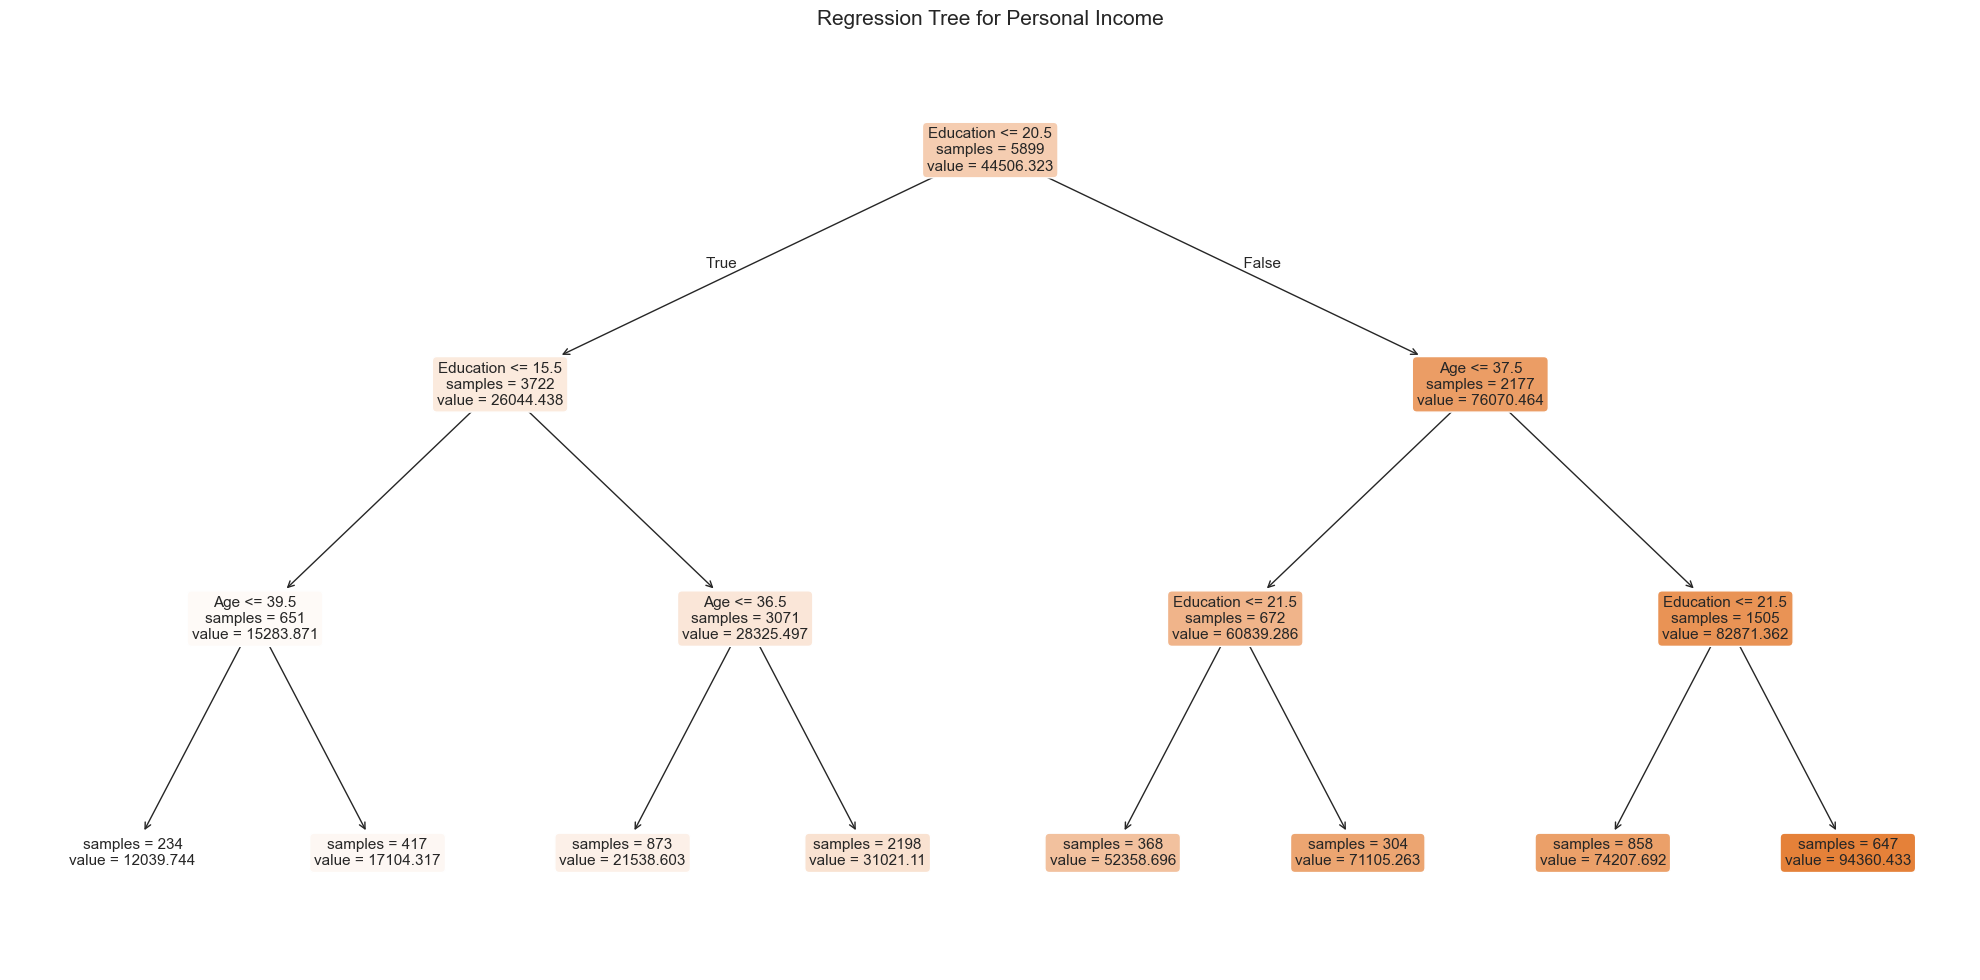

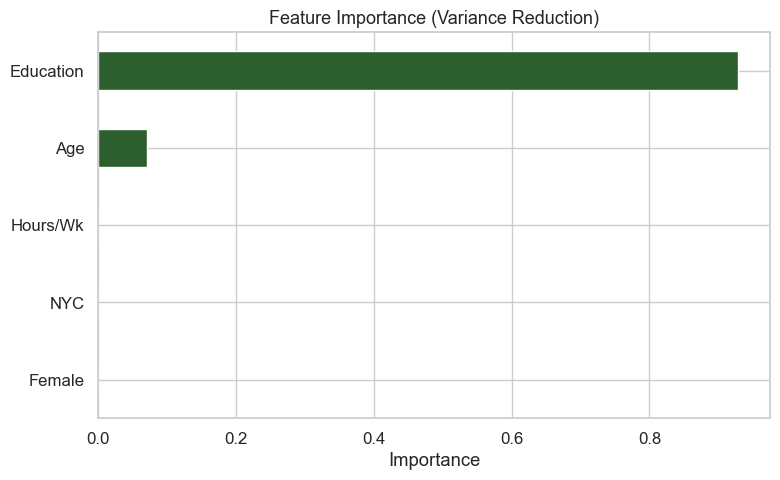

R-squared on training data: 0.592
(Shallow tree intentionally trades fit for interpretability)


In [28]:
# Regression tree: which variable combinations best explain income?
tree_data = working.copy()

# Encode features for the tree
tree_data['is_female'] = (tree_data['SEX'] == 2).astype(int)
tree_data['is_nyc'] = tree_data['PUMA'].str.contains('NYC').astype(int)
tree_data['edu_numeric'] = tree_data['SCHL'].clip(lower=0)  # treat -1 as 0

feature_cols = ['AGEP', 'edu_numeric', 'is_female', 'is_nyc', 'WKHP']
target_col = 'PINCP'

tree_subset = tree_data[feature_cols + [target_col]].dropna()
X_tree = tree_subset[feature_cols]
y_tree = tree_subset[target_col]

reg_tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=120, random_state=42)
reg_tree.fit(X_tree, y_tree)

# --- Plot 1: Full-width regression tree ---
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(reg_tree, feature_names=['Age', 'Education', 'Female', 'NYC', 'Hours/Wk'],
          filled=True, rounded=True, fontsize=11, ax=ax,
          proportion=False, impurity=False)
ax.set_title('Regression Tree for Personal Income', fontsize=15)
plt.tight_layout()
plt.show()

# --- Plot 2: Feature importance bar chart ---
fig, ax = plt.subplots(figsize=(8, 5))
importances = pd.Series(reg_tree.feature_importances_,
                        index=['Age', 'Education', 'Female', 'NYC', 'Hours/Wk'])
importances.sort_values().plot(kind='barh', color='#2C5F2D', edgecolor='white', ax=ax)
ax.set_title('Feature Importance (Variance Reduction)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(f'R-squared on training data: {reg_tree.score(X_tree, y_tree):.3f}')
print(f'(Shallow tree intentionally trades fit for interpretability)')

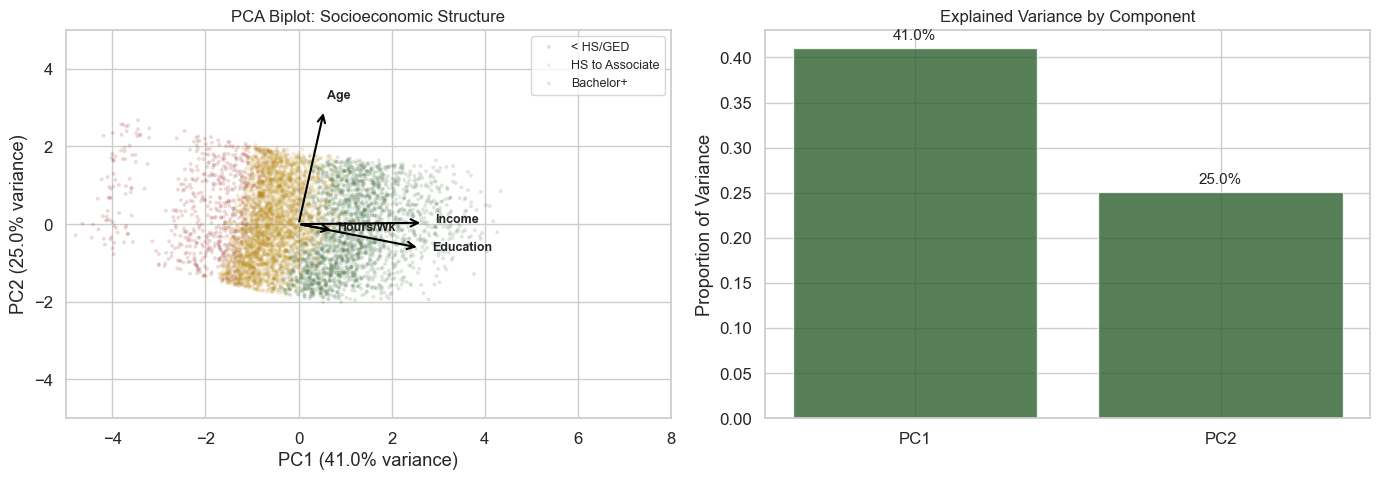

Total variance explained by 2 components: 66.0%


In [27]:
# PCA biplot: reveal latent socioeconomic dimensions
pca_data = working[['AGEP', 'SCHL', 'WKHP', 'PINCP', 'PWGTP', 'SEX']].dropna().copy()
pca_data['SCHL'] = pca_data['SCHL'].clip(lower=0)
pca_features = ['AGEP', 'SCHL', 'WKHP', 'PINCP']

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(pca_data[pca_features])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PCA scatter colored by education group
edu_groups = pd.cut(pca_data['SCHL'], bins=[-1, 15, 20, 24],
                    labels=['< HS/GED', 'HS to Associate', 'Bachelor+'])
colors_map = {'< HS/GED': '#8B0000', 'HS to Associate': '#B8860B', 'Bachelor+': '#2C5F2D'}
for grp in ['< HS/GED', 'HS to Associate', 'Bachelor+']:
    mask = edu_groups == grp
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.15, s=8,
                    color=colors_map[grp], label=grp, edgecolors='none')

# Overlay loading vectors (biplot arrows)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
feature_labels = ['Age', 'Education', 'Hours/Wk', 'Income']
for i, label in enumerate(feature_labels):
    axes[0].annotate('', xy=(loadings[i, 0] * 3, loadings[i, 1] * 3), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    axes[0].text(loadings[i, 0] * 3.3, loadings[i, 1] * 3.3, label, fontsize=9,
                 fontweight='bold')

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('PCA Biplot: Socioeconomic Structure', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_xlim(-5, 8)
axes[0].set_ylim(-5, 5)

# Right: explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[1].bar([1, 2], pca.explained_variance_ratio_, color='#2C5F2D', edgecolor='white', alpha=0.8)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['PC1', 'PC2'])
axes[1].set_title('Explained Variance by Component', fontsize=12)
axes[1].set_ylabel('Proportion of Variance')
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[1].text(i + 1, v + 0.01, f'{v:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Total variance explained by 2 components: {cumvar[-1]:.1%}')

The regression tree confirms what the boxplots suggested: education is the dominant predictor of income, appearing as the first split. But the tree goes further by showing the conditional effects. Among the highly educated, hours worked per week becomes the next discriminator (full-time vs part-time), while among those with less education, age (experience proxy) matters more. The feature importance plot quantifies education's outsized contribution relative to the other variables.

The PCA biplot compresses four dimensions into two. PC1 runs along the education/income axis, representing the "socioeconomic status" dimension. PC2 captures age-related variation that is orthogonal to income. The loading arrows reveal that education and income point in nearly the same direction, quantifying their tight coupling. The color-coded scatter shows clean separation between education groups along PC1, confirming that a single latent dimension captures most of the income structure in this population.

## T: Tell — Synthesis and Communication

Key findings from the Census ACS dataset:

1. Coded missing values are the primary data quality trap. Income topcoding (9999999) inflated the naive mean by a substantial amount. The ACS codebook is essential reading before any analysis; what appears to be data may encode missingness, non-applicability, or administrative censoring. This is the kind of discovery that triggers the Quality Loop, sending us back to U to reassess our understanding of the data before proceeding.

2. Survey weights change substantive conclusions. Unweighted and weighted median incomes differ both in magnitude and in the relative ranking of geographic regions. Any publication of ACS results without weights produces biased population estimates.

3. Education is ordinal, not nominal. The income-education relationship is monotonically increasing, and encoding education as an unordered categorical variable would lose this structure.

4. Income follows a log-normal distribution with heavy right skew. Median is the appropriate measure of central tendency; mean is distorted by the long right tail.

5. The regression tree and PCA from the model-based discovery component confirmed education as the dominant factor and revealed conditional effects (hours worked matters more for the highly educated, while age/experience matters more for those with less education). The PCA biplot compressed the socioeconomic structure into a single visualization showing that one latent dimension captures most of the income variation.

6. Feature engineering candidates: education categories collapsed into meaningful groups (less than HS, HS, some college, bachelor+, graduate), NYC vs non-NYC binary, income-to-hours ratio for hourly rate estimation.

Discovery Loop: The gender pay gap visible in the bar charts persists across education levels, raising a question for the next iteration: does controlling for occupation group, hours worked, and age fully explain the gap, or does a residual remain? That question was not in the original charter but emerged from the Study phase.

---

# Cross-Dataset Reflections Through the QUEST Lens

These three datasets illustrate how each phase of the QUEST framework surfaces different categories of analytical challenges:

| QUEST Phase | Hospital | EPA | Census |
|-------------|----------|-----|--------|
| Q: Question | Clinical quality improvement; readmission drivers | Regulatory compliance; spatial-temporal PM2.5 patterns | Demographic income structure; survey methodology effects |
| U: Understand | Inconsistent coding (gender, race, diagnosis); MNAR creatinine | Sensor errors (negative values, >200); structured maintenance gaps | Coded missing (9999999 topcodes); survey weight requirements |
| E: Explore | Log-normal LOS; age data entry errors; class imbalance | Heavy right tail with legitimate extreme events; seasonal modality | Log-normal income; ordinal education; high-cardinality categoricals |
| S: Study | Classification tree reveals comorbidity as primary splitter with threshold effects | K-Means clustering confirms geographic gradient; temperature-PM2.5 photochemistry | Regression tree ranks education first; PCA compresses socioeconomic structure |
| T: Tell | Quality Loop needed for coding remediation; new question on subgroup-specific drivers | Domain knowledge distinguishes sensor errors from wildfire smoke | Weighted vs unweighted estimates change rankings; gender gap persists across education |

The three iteration loops appeared naturally across all datasets. The Quality Loop surfaced when coded missing values in the Census data and MNAR patterns in the hospital data required returning to U for deeper inspection. The Modeling Loop appeared when the classification tree's threshold values prompted re-examination of the univariate distributions around those cutpoints. The Discovery Loop generated new questions at the end of each case study that were not in the original analytical charter.

The common thread across all three: no automated tool could distinguish sensor errors from wildfire smoke, data entry mistakes from rare clinical presentations, or topcoded values from legitimate high incomes. Human judgment, domain expertise, and the analytical disposition Tukey described remain irreplaceable even in an era of automated profiling and LLM co-pilots. The QUEST framework provides the scaffolding that ensures this judgment is applied systematically rather than haphazardly.

---

## References

Tukey, J.W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

Behrens, J.T. (1997). Principles and Procedures of Exploratory Data Analysis. *Psychological Methods*, 2(2), 131-160.

Wickham, H. and Grolemund, G. (2017). *R for Data Science*. O'Reilly.

Wilke, C.O. (2019). *Fundamentals of Data Visualization*. O'Reilly.

Rubin, D.B. (1976). Inference and Missing Data. *Biometrika*, 63(3), 581-592.